# Question 20: Is being left-handed associated with a higher win rate against right-handed players?

Using `home_team`, `away_team`, `event`

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

TEAM_DATA_ROOT = DATA_ROOT / "Data"

In [4]:
match_event = pd.read_parquet(TEAM_DATA_ROOT / "event.parquet")
home_team = pd.read_parquet(TEAM_DATA_ROOT / "home_team.parquet")
away_team = pd.read_parquet(TEAM_DATA_ROOT / "away_team.parquet")

print("Home plays:", home_team["plays"].value_counts(dropna=False))
print("\nAway plays:", away_team["plays"].value_counts(dropna=False))

Home plays: plays
NaN             13126
right-handed    11106
left-handed      1378
Name: count, dtype: int64

Away plays: plays
NaN             12244
right-handed    10494
left-handed      1465
Name: count, dtype: int64


In [6]:
# Keep the latest record for each match

match_event_final = (match_event.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

home_final = (home_team.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

away_final = (away_team.sort_values(["match_id", "snapshot_date"]).drop_duplicates(subset="match_id", keep="last"))

print("Event matches:", len(match_event_final))
print("Home matches:", len(home_final))
print("Away matches:", len(away_final))

Event matches: 16873
Home matches: 12389
Away matches: 11690


In [7]:
# Combine match results with player handedness

matches = (
    match_event_final[["match_id", "winner_code"]]
    .merge(home_final[["match_id", "plays"]].rename(columns={"plays": "home_plays"}), on="match_id", how="inner")
    .merge(away_final[["match_id", "plays"]].rename(columns={"plays": "away_plays"}), on="match_id", how="inner"))

print("Matches available for analysis:", len(matches))

matches.head()

Matches available for analysis: 9882


,match_id,winner_code,home_plays,away_plays
0,11998445,2.0,right-handed,right-handed
1,11998446,2.0,right-handed,right-handed
2,11998447,1.0,right-handed,right-handed
3,11998448,1.0,right-handed,right-handed
4,11998449,2.0,right-handed,right-handed


In [15]:
#  only matches between left-handed and right-handed players

mixed_handed = matches[
    matches["home_plays"].notna()
    & matches["away_plays"].notna()
    & (matches["home_plays"] != matches["away_plays"])
    & matches["winner_code"].isin([1, 2])
].copy()

print("Valid left vs right matches:", len(mixed_handed))

Valid left vs right matches: 802


In [16]:
# Create one record per player in left-vs-right matches

home_players = mixed_handed[["home_plays", "winner_code"]].copy()
home_players = home_players.rename(columns={"home_plays": "plays"})
home_players["won"] = home_players["winner_code"] == 1

away_players = mixed_handed[["away_plays", "winner_code"]].copy()
away_players = away_players.rename(columns={"away_plays": "plays"})
away_players["won"] = away_players["winner_code"] == 2

players = pd.concat([home_players, away_players], ignore_index=True)

players[["plays", "won"]].head()

,plays,won
0,left-handed,False
1,left-handed,True
2,right-handed,False
3,left-handed,True
4,left-handed,True


In [17]:
# Calculate win rate by handedness

handedness_stats = (players.groupby("plays").agg(matches=("won", "size"), wins=("won", "sum")))

handedness_stats["win_rate"] = (handedness_stats["wins"] / handedness_stats["matches"] * 100)

handedness_stats

,matches,wins,win_rate
plays,,,
left-handed,802,400,49.875312
right-handed,802,402,50.124688


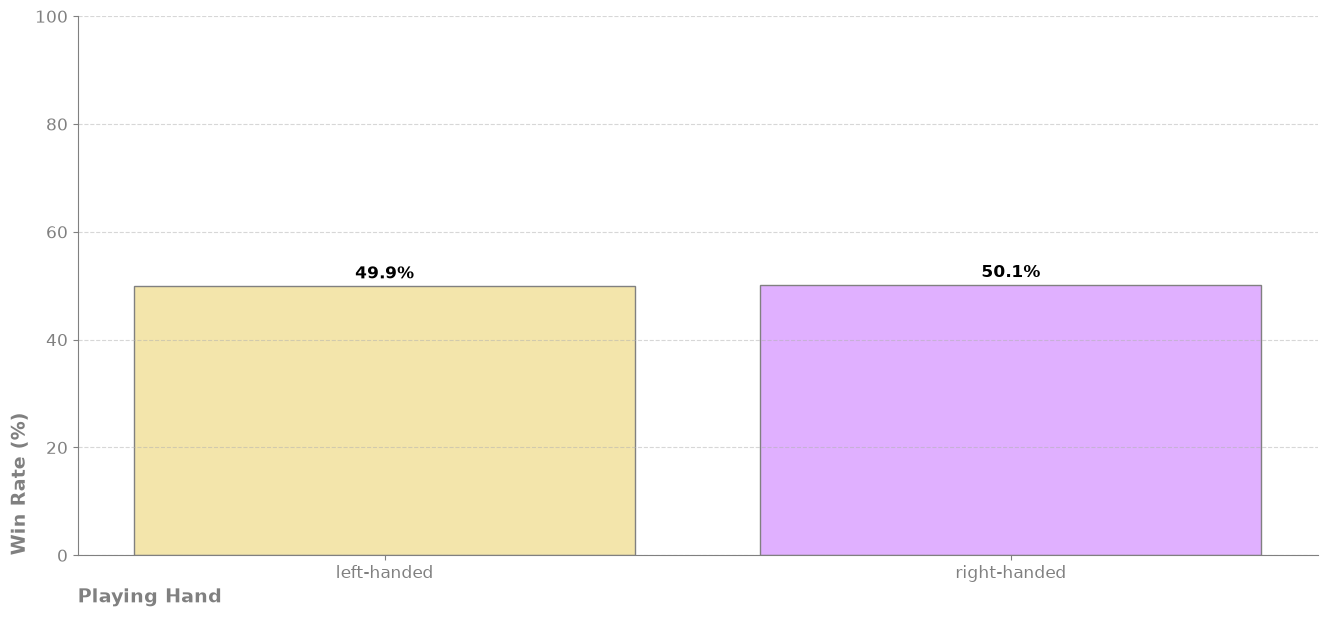

In [23]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(
    handedness_stats.index,
    handedness_stats["win_rate"],
    color=["#F3E5AB", "#E0B0FF"],
    edgecolor="gray")

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_xlabel("Playing Hand", loc="left", weight="bold", color="gray", fontsize=14)
ax.set_ylabel("Win Rate (%)", loc="bottom", weight="bold", color="gray", fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

ax.set_ylim(0, 100)

ax.grid(axis="y", linestyle="--", alpha=0.5)

for i, value in enumerate(handedness_stats["win_rate"]):
    ax.text(i, value + 1.5, f"{value:.1f}%", ha="center", fontsize=12, weight="bold")

plt.show()

The win rate for left-handed and right-handed players is roughly the same. In matches between left-handed and right-handed players, left-handed players won 400 of 802 matches (49.9%), while right-handed players won 402 of 802 matches (50.1%). The win rates are nearly identical, suggesting no noticeable handedness advantage in this dataset.